# 전국 시군구별 교육의 질·교육환경 종합 EDA

이 노트북은 팀플의 교육 분야 분석을 정리한 **실행 가능한 보고서형 노트북**이다. 최종 목적은 전국 시군구 중 학생과 학부모가 실제로 체감하는 교육환경이 우수한 지역 TOP 15를 산출하는 것이다.

이번 분석은 단순히 학교 수가 많거나 교원 1인당 학생수가 낮은 지역을 찾는 방식이 아니다. 그런 방식은 학생 수가 적은 농어촌·도서 지역이 과대평가될 수 있다. 따라서 사교육 접근성, 학교 인프라, 지역 교육 수요, 재정 여건, 통계적 안정성을 함께 반영했다.

## 1. 분석 목적

교육 분야 점수는 최종적으로 다른 분야, 예를 들어 주거, 건강, 고용, 안전 지표와 결합되어 삶의 질 지표에 들어갈 수 있어야 한다. 따라서 교육 분석의 목적은 “공공 교육자원 투입량이 많은 지역”을 찾는 것이 아니라, 실제 생활에서 교육환경이 좋다고 체감될 가능성이 높은 지역을 찾는 것이다.

이 분석에서 교육환경은 다음 질문을 기준으로 판단했다.

- 사교육 및 교육시설에 접근하기 쉬운가?
- 학교와 교원 등 기본 교육 인프라가 충분한가?
- 학생 수와 인구 규모가 충분해 교육 수요가 안정적인가?
- 지역 재정 여건이 교육환경을 뒷받침할 가능성이 있는가?
- 학생 수가 너무 적은 지역이 비율 지표 때문에 과대평가되지 않았는가?

다만 KOSIS e-지방지표에는 시군구 단위의 학업성취도, 대학 진학률, 특목고·자사고 진학률이 직접 제공되지 않는다. 그래서 학업 성과 및 진학 환경은 사교육 접근성, 재정자립도, 교육 수요를 이용한 대체지표로 구성했다.

## 2. 분석 환경과 데이터 불러오기

데이터는 KOSIS e-지방지표에서 수집한 2016~2024년 시군구별 교육·인구·재정 지표다. 분석 단위는 `시군구-연도`이다.

스크립트에서 수집한 원자료는 long 형태 CSV로 저장되어 있고, 분석용 데이터는 wide 형태 CSV로 저장되어 있다. 이 노트북에서는 저장된 데이터를 불러온 뒤 점수 계산 과정을 코드로 다시 확인한다.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)


def find_project_root(start: Path | None = None) -> Path:
    current = Path.cwd() if start is None else start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "education" / "data" / "education_quality_environment_2016_2024.csv").exists():
            return candidate
    raise FileNotFoundError("socialInteligence 저장소 안에서 실행해야 합니다.")


ROOT = find_project_root()
DATA_DIR = ROOT / "education" / "data"
VIZ_DIR = ROOT / "education" / "viz"

long_df = pd.read_csv(DATA_DIR / "education_quality_environment_2016_2024_long.csv", dtype={"region_cd": str})
features_saved = pd.read_csv(DATA_DIR / "education_quality_environment_2016_2024.csv", dtype={"region_cd": str})
top15_saved = pd.read_csv(DATA_DIR / "education_quality_environment_top15_2024.csv")

latest_year = int(features_saved["year"].max())
latest_saved = features_saved[features_saved["year"] == latest_year].copy()

print("프로젝트 루트:", ROOT)
print("분석 기간:", int(features_saved["year"].min()), "~", latest_year)
print("최신연도 분석 지역 수:", latest_saved["region"].nunique())

프로젝트 루트: C:\Users\danie\Desktop\socialInteligence
분석 기간: 2016 ~ 2024
최신연도 분석 지역 수: 229


## 3. 사용한 자료

사용한 자료는 모두 KOSIS e-지방지표에서 가져온 시군구 단위 자료다. 분석 기간은 2016년부터 2024년까지이다.

원자료는 처음에 다음과 같은 long 형태다.

```text
시군구 | 연도 | 지표명 | 값
```

예를 들어 `서울 강남구 | 2024 | 인구 천명당 사설학원수 | 4.6` 같은 방식이다. 이후 분석을 위해 pandas `pivot_table`을 사용해 한 행이 하나의 `시군구-연도`가 되도록 wide 형태로 바꾸었다.

In [2]:
overview = pd.DataFrame({
    "항목": [
        "long 데이터 행 수",
        "분석용 wide 데이터 행 수",
        "분석 시작연도",
        "분석 최신연도",
        "최신연도 시군구 수",
        "사용 지표 수",
    ],
    "값": [
        f"{len(long_df):,}행",
        f"{len(features_saved):,}행",
        int(features_saved["year"].min()),
        int(features_saved["year"].max()),
        latest_saved["region"].nunique(),
        long_df["metric_id"].nunique(),
    ],
})

display(overview)
display(long_df.head(10))

,항목,값
0,long 데이터 행 수,"18,840행"
1,분석용 wide 데이터 행 수,"2,059행"
2,분석 시작연도,2016
3,분석 최신연도,2024
4,최신연도 시군구 수,229
5,사용 지표 수,9


,region_cd,province,district,region,year,metric_id,metric_name,category,direction,value
0,11010,서울,종로구,서울 종로구,2016,private_academies_per_1000,인구 천명당 사설학원수,사교육 및 교육시설 접근성,higher,1.8
1,11020,서울,중구,서울 중구,2016,private_academies_per_1000,인구 천명당 사설학원수,사교육 및 교육시설 접근성,higher,1.0
2,11030,서울,용산구,서울 용산구,2016,private_academies_per_1000,인구 천명당 사설학원수,사교육 및 교육시설 접근성,higher,0.7
3,11040,서울,성동구,서울 성동구,2016,private_academies_per_1000,인구 천명당 사설학원수,사교육 및 교육시설 접근성,higher,0.9
4,11050,서울,광진구,서울 광진구,2016,private_academies_per_1000,인구 천명당 사설학원수,사교육 및 교육시설 접근성,higher,1.2
5,11060,서울,동대문구,서울 동대문구,2016,private_academies_per_1000,인구 천명당 사설학원수,사교육 및 교육시설 접근성,higher,1.0
6,11070,서울,중랑구,서울 중랑구,2016,private_academies_per_1000,인구 천명당 사설학원수,사교육 및 교육시설 접근성,higher,0.7
7,11080,서울,성북구,서울 성북구,2016,private_academies_per_1000,인구 천명당 사설학원수,사교육 및 교육시설 접근성,higher,1.0
8,11090,서울,강북구,서울 강북구,2016,private_academies_per_1000,인구 천명당 사설학원수,사교육 및 교육시설 접근성,higher,0.7
9,11100,서울,도봉구,서울 도봉구,2016,private_academies_per_1000,인구 천명당 사설학원수,사교육 및 교육시설 접근성,higher,1.1


## 4. 지표 분류표

교육의 질과 교육환경은 하나의 변수로 판단하기 어렵다. 그래서 확보 가능한 지표를 평가 영역별로 분류했다.

특히 학업 성과와 진학 환경은 원래 학업성취도, 대학 진학률, 특목고·자사고 진학률 같은 직접 지표가 필요하다. 하지만 현재 데이터에는 없기 때문에, 사교육 접근성, 재정자립도, 교육 수요를 이용한 대체지표로 구성했다.

In [3]:
indicator_table = pd.DataFrame([
    ["학업 성과 및 진학 환경", "직접 지표 없음", "사교육 접근성, 재정자립도, 교육 수요로 대체", "높을수록 우수"],
    ["사교육 및 교육시설 접근성", "인구 천명당 사설학원수", "학원 접근성과 사교육 인프라 밀도", "높을수록 우수"],
    ["학교 인프라", "초등학교수", "지역 내 기본 학교 자원 규모", "높을수록 우수"],
    ["학교 인프라", "초등학교 교원수", "교원 자원 규모", "높을수록 우수"],
    ["학교 인프라", "유치원수", "기초 교육시설 규모", "높을수록 우수"],
    ["학교 인프라", "교원 1인당 학생수", "학생 대비 교원 여건", "낮을수록 우수"],
    ["학교 인프라", "학급당 학생수", "학급 규모 여건", "낮을수록 우수"],
    ["지역 교육 수요", "초등학교 학생수", "학령인구 규모의 대체지표", "높을수록 안정적"],
    ["지역 교육 수요", "주민등록인구", "지역 규모와 수요 기반", "높을수록 안정적"],
    ["교육 소비 여력", "재정자립도", "지역 재정·경제 여건 대체지표", "높을수록 우수"],
], columns=["평가 영역", "사용 지표", "해석", "방향성"])

display(indicator_table)

,평가 영역,사용 지표,해석,방향성
0,학업 성과 및 진학 환경,직접 지표 없음,"사교육 접근성, 재정자립도, 교육 수요로 대체",높을수록 우수
1,사교육 및 교육시설 접근성,인구 천명당 사설학원수,학원 접근성과 사교육 인프라 밀도,높을수록 우수
2,학교 인프라,초등학교수,지역 내 기본 학교 자원 규모,높을수록 우수
3,학교 인프라,초등학교 교원수,교원 자원 규모,높을수록 우수
4,학교 인프라,유치원수,기초 교육시설 규모,높을수록 우수
5,학교 인프라,교원 1인당 학생수,학생 대비 교원 여건,낮을수록 우수
6,학교 인프라,학급당 학생수,학급 규모 여건,낮을수록 우수
7,지역 교육 수요,초등학교 학생수,학령인구 규모의 대체지표,높을수록 안정적
8,지역 교육 수요,주민등록인구,지역 규모와 수요 기반,높을수록 안정적
9,교육 소비 여력,재정자립도,지역 재정·경제 여건 대체지표,높을수록 우수


## 5. 점수 계산 전에 수행한 EDA

점수를 만들기 전에 먼저 지표의 분포와 문제점을 확인했다.

첫째, `교원 1인당 학생수`와 `학급당 학생수`는 낮을수록 좋은 지표이지만, 이 지표만 크게 반영하면 학생 수가 적은 농어촌·도서 지역이 과도하게 높게 나온다. 학생 수가 적어서 교원 1인당 학생수가 낮은 것과 교육환경이 우수한 것은 다르기 때문이다.

둘째, `초등학교수`, `초등학생수`, `주민등록인구` 같은 규모 지표는 행정구역이 큰 도시가 유리하다. 그래서 규모 지표는 그대로 비교하지 않고 `log1p` 변환을 적용했다.

셋째, 극단값이 전체 점수를 좌우하지 않도록 1~99% winsorization을 적용했다. 5~95%로 너무 강하게 자르면 강남구처럼 실제로 사설학원 밀도가 매우 높은 지역의 차이가 사라질 수 있기 때문에 1~99%를 사용했다.

In [4]:
metric_counts = (
    long_df.groupby(["year", "metric_id"])["region"].nunique()
    .reset_index(name="지역 수")
    .pivot(index="metric_id", columns="year", values="지역 수")
)

display(metric_counts)

raw_latest = long_df[long_df["year"] == latest_year]
raw_distribution = raw_latest.groupby("metric_id")["value"].describe().round(2)
display(raw_distribution)

year,2016,2017,2018,2019,2020,2021,2022,2023,2024
metric_id,,,,,,,,,
class_size_total,229,229,229,229,229,229,229,229,229
elementary_schools,229,229,229,229,229,229,229,229,229
elementary_students,229,229,229,229,229,229,229,229,229
elementary_teachers,229,229,229,229,229,229,229,229,229
fiscal_self_reliance,229,229,229,229,229,229,229,229,229
kindergartens,229,229,229,229,229,229,229,229,229
population,261,261,261,261,261,261,261,261,264
private_academies_per_1000,229,229,229,229,229,229,229,229,229
teacher_per_student,229,229,229,229,229,229,229,229,229


,count,mean,std,min,25%,50%,75%,max
metric_id,,,,,,,,
class_size_total,229.0,18.18,4.32,7.72,13.96,19.62,21.68,25.01
elementary_schools,229.0,27.00,19.22,4.00,14.00,21.00,33.00,112.00
elementary_students,229.0,10895.22,12344.32,209.00,1644.00,6111.00,15318.00,68660.00
elementary_teachers,229.0,858.51,840.06,43.00,242.00,552.00,1177.00,4636.00
fiscal_self_reliance,229.0,19.14,10.90,6.69,10.79,16.17,24.12,57.53
kindergartens,229.0,36.22,32.26,3.00,15.00,25.00,44.00,190.00
population,264.0,231317.25,211370.41,9099.00,59373.00,187810.50,338747.50,1193005.00
private_academies_per_1000,229.0,1.39,0.68,0.10,0.90,1.30,1.80,4.60
teacher_per_student,229.0,11.50,4.15,3.39,7.88,12.18,14.25,24.01


## 6. long 데이터를 wide 데이터로 변환

pandas `pivot_table`을 사용해 `시군구-연도-지표-값` 구조를 `시군구-연도` 기준의 분석용 데이터로 변환한다. 필수 지표가 없는 행은 최종 점수 계산에서 제외한다.

In [5]:
features = (
    long_df.pivot_table(
        index=["region_cd", "province", "district", "region", "year"],
        columns="metric_id",
        values="value",
        aggfunc="first",
    )
    .reset_index()
    .rename_axis(None, axis=1)
)

required_metrics = [
    "private_academies_per_1000",
    "elementary_students",
    "elementary_schools",
    "elementary_teachers",
    "kindergartens",
    "teacher_per_student",
    "class_size_total",
    "population",
    "fiscal_self_reliance",
]

missing_before = features[required_metrics].isna().sum().to_frame("결측치 수")
features = features.dropna(subset=required_metrics).copy()

print("wide 데이터 크기:", features.shape)
display(missing_before)
display(features.head())

wide 데이터 크기: (2059, 14)


,결측치 수
private_academies_per_1000,293
elementary_students,293
elementary_schools,293
elementary_teachers,293
kindergartens,293
teacher_per_student,293
class_size_total,293
population,2
fiscal_self_reliance,293


,region_cd,province,district,region,year,class_size_total,elementary_schools,elementary_students,elementary_teachers,fiscal_self_reliance,kindergartens,population,private_academies_per_1000,teacher_per_student
0,11010,서울,종로구,서울 종로구,2016,25.57,13.0,5686.0,451.0,50.36,17.0,152737.0,1.8,18.47
1,11010,서울,종로구,서울 종로구,2017,24.60,13.0,5561.0,466.0,50.77,17.0,154770.0,1.9,18.39
2,11010,서울,종로구,서울 종로구,2018,23.20,13.0,5507.0,446.0,47.37,17.0,153065.0,1.8,17.95
3,11010,서울,종로구,서울 종로구,2019,22.15,13.0,5463.0,439.0,47.41,17.0,151290.0,1.7,17.68
4,11010,서울,종로구,서울 종로구,2020,21.14,13.0,5192.0,452.0,46.96,17.0,149384.0,1.6,17.26


## 7. 전처리 및 표준화 함수

각 지표는 다음 순서로 처리했다.

1. 숫자형으로 변환
2. 필요한 경우 `log1p` 변환
3. 1~99% winsorization으로 극단값 보정
4. 0~100점 min-max scaling
5. 낮을수록 좋은 지표는 `100 - score`로 방향 반전

연도별로 따로 표준화한 이유는 각 연도 안에서 지역 간 상대적 위치를 비교하기 위해서다.

In [6]:
def winsorized_minmax(
    series: pd.Series,
    *,
    lower_is_better: bool = False,
    log_transform: bool = False,
    lower_q: float = 0.01,
    upper_q: float = 0.99,
) -> pd.Series:
    values = pd.to_numeric(series, errors="coerce")

    if log_transform:
        values = np.log1p(values.clip(lower=0))

    lo = values.quantile(lower_q)
    hi = values.quantile(upper_q)
    values = values.clip(lo, hi)

    min_value = values.min()
    max_value = values.max()
    if pd.isna(min_value) or pd.isna(max_value) or min_value == max_value:
        score = pd.Series(50.0, index=series.index)
    else:
        score = (values - min_value) / (max_value - min_value) * 100

    return 100 - score if lower_is_better else score

## 8. 지표별 0~100점 생성

아래 코드는 각 원지표를 연도별 0~100점으로 바꾼다. 인구, 학생수, 학교수, 교원수처럼 규모 차이가 큰 지표에는 log scaling을 적용했다. 교원 1인당 학생수와 학급당 학생수는 낮을수록 좋은 지표이므로 방향을 반전했다.

In [7]:
score_config = {
    "private_academies_per_1000": {"lower_is_better": False, "log_transform": False},
    "elementary_students": {"lower_is_better": False, "log_transform": True},
    "elementary_schools": {"lower_is_better": False, "log_transform": True},
    "elementary_teachers": {"lower_is_better": False, "log_transform": True},
    "kindergartens": {"lower_is_better": False, "log_transform": True},
    "teacher_per_student": {"lower_is_better": True, "log_transform": False},
    "class_size_total": {"lower_is_better": True, "log_transform": False},
    "population": {"lower_is_better": False, "log_transform": True},
    "fiscal_self_reliance": {"lower_is_better": False, "log_transform": False},
}

for col, config in score_config.items():
    features[f"{col}_score"] = features.groupby("year")[col].transform(
        lambda item: winsorized_minmax(item, **config)
    )

score_preview_cols = ["region", "year"] + [f"{col}_score" for col in score_config]
display(features[features["year"] == latest_year][score_preview_cols].head(10).round(2))

,region,year,private_academies_per_1000_score,elementary_students_score,elementary_schools_score,elementary_teachers_score,kindergartens_score,teacher_per_student_score,class_size_total_score,population_score,fiscal_self_reliance_score
8,서울 종로구,2024,45.26,48.11,32.89,38.58,29.39,30.82,29.51,48.72,72.45
17,서울 중구,2024,20.89,48.95,30.39,36.97,23.45,15.94,32.30,45.23,96.36
26,서울 용산구,2024,13.93,53.14,37.37,46.27,23.45,42.15,35.76,58.53,66.98
35,서울 성동구,2024,27.86,63.52,48.07,58.10,45.72,28.13,33.32,65.98,47.94
44,서울 광진구,2024,34.82,68.55,48.07,59.95,41.18,3.26,8.63,70.87,33.61
53,서울 동대문구,2024,31.34,69.06,48.07,60.24,43.54,11.53,14.89,71.38,30.20
62,서울 중랑구,2024,13.93,69.32,52.37,61.93,48.73,39.95,24.54,74.24,17.56
71,서울 성북구,2024,27.86,75.85,58.50,70.10,59.83,4.42,19.10,76.91,24.20
80,서울 강북구,2024,17.41,59.84,35.20,50.36,31.14,46.56,18.83,66.88,17.39
89,서울 도봉구,2024,24.37,68.29,51.00,59.98,45.72,44.78,22.57,68.57,21.35


## 9. 영역별 점수 계산

최종 점수는 한 번에 만들지 않고 5개 영역별 점수를 먼저 만든다.

### 사교육 접근성

```text
사교육 접근성 = 인구 천명당 사설학원수 75% + 재정자립도 15% + 초등학생 규모 10%
```

### 학교 인프라

```text
학교 인프라 = 초등학교 교원수 25% + 초등학교수 20% + 유치원수 15% + 학급당 학생수 20% + 교원 1인당 학생수 20%
```

### 지역 교육 수요

```text
지역 교육 수요 = 재정자립도 55% + 초등학생 규모 20% + 주민등록인구 15% + 초등학교수 10%
```

### 안정성

```text
안정성 = 초등학생 규모 50% + 주민등록인구 30% + 초등학교수 20%
```

### 학업·진학 대체점수

```text
학업·진학 대체점수 = 사교육 접근성 50% + 재정자립도 35% + 지역 교육 수요 15%
```

In [8]:
features["stability_score"] = (
    features["elementary_students_score"] * 0.50
    + features["population_score"] * 0.30
    + features["elementary_schools_score"] * 0.20
)

features["private_education_access_score"] = (
    features["private_academies_per_1000_score"] * 0.75
    + features["fiscal_self_reliance_score"] * 0.15
    + features["elementary_students_score"] * 0.10
)

features["school_infra_score"] = (
    features["elementary_teachers_score"] * 0.25
    + features["elementary_schools_score"] * 0.20
    + features["kindergartens_score"] * 0.15
    + features["class_size_total_score"] * 0.20
    + features["teacher_per_student_score"] * 0.20
)

features["education_demand_score"] = (
    features["fiscal_self_reliance_score"] * 0.55
    + features["elementary_students_score"] * 0.20
    + features["population_score"] * 0.15
    + features["elementary_schools_score"] * 0.10
)

features["academic_admissions_proxy_score"] = (
    features["private_education_access_score"] * 0.50
    + features["fiscal_self_reliance_score"] * 0.35
    + features["education_demand_score"] * 0.15
)

component_cols = [
    "academic_admissions_proxy_score",
    "private_education_access_score",
    "school_infra_score",
    "education_demand_score",
    "stability_score",
]

display(features[features["year"] == latest_year][["region", *component_cols]].head(10).round(2))

,region,academic_admissions_proxy_score,private_education_access_score,school_infra_score,education_demand_score,stability_score
8,서울 종로구,59.18,49.63,32.70,60.07,45.25
17,서울 중구,62.13,35.02,28.49,72.61,44.12
26,서울 용산구,45.35,25.81,38.14,59.99,51.61
35,서울 성동구,42.06,34.43,43.29,53.78,61.17
44,서울 광진구,37.91,38.01,33.16,47.63,65.15
53,서울 동대문구,34.93,34.94,36.49,45.94,65.56
62,서울 중랑구,22.13,20.01,46.16,39.89,67.41
71,서울 성북구,31.40,32.11,42.90,45.87,72.70
80,서울 강북구,22.17,21.65,37.38,35.08,57.02
89,서울 도봉구,27.75,28.31,45.52,40.79,64.91


## 10. 최종 교육환경 종합점수

최종 종합점수는 다음 공식으로 계산했다.

```text
교육환경 종합점수 = 학업·진학 대체점수 30% + 사교육 접근성 30% + 학교 인프라 20% + 지역 교육 수요 15% + 안정성 5%
```

학업·진학 대체점수와 사교육 접근성 비중을 높게 둔 이유는 이번 분석의 목표가 단순 공공자원 투입량이 아니라 학생과 학부모가 체감하는 교육환경이기 때문이다. 학교 인프라와 교육 수요도 함께 반영했고, 작은 지역의 비율 지표 과대평가를 막기 위해 안정성 점수를 포함했다.

In [9]:
features["education_quality_score"] = (
    features["academic_admissions_proxy_score"] * 0.30
    + features["private_education_access_score"] * 0.30
    + features["school_infra_score"] * 0.20
    + features["education_demand_score"] * 0.15
    + features["stability_score"] * 0.05
)

latest = features[features["year"] == latest_year].copy()
latest = latest.sort_values("education_quality_score", ascending=False).reset_index(drop=True)
latest["rank"] = latest.index + 1

top15 = latest.head(15).copy()

display(top15[[
    "rank",
    "region",
    "education_quality_score",
    "academic_admissions_proxy_score",
    "school_infra_score",
    "private_education_access_score",
    "education_demand_score",
    "stability_score",
]].round(2))

,rank,region,education_quality_score,academic_admissions_proxy_score,school_infra_score,private_education_access_score,education_demand_score,stability_score
0,1,서울 강남구,86.34,97.80,49.39,98.39,90.74,79.86
1,2,세종 세종시,86.09,94.59,61.76,91.69,91.65,82.10
2,3,서울 서초구,79.94,91.11,46.34,90.02,84.75,72.40
3,4,경기 성남시,79.73,86.50,61.98,73.92,96.96,93.23
4,5,경기 화성시,78.90,81.81,67.07,73.01,93.79,99.39
5,6,경기 용인시,75.84,78.77,64.39,67.64,93.57,100.00
6,7,전북 전주시,71.24,63.53,63.02,88.60,56.90,89.21
7,8,경기 수원시,71.10,68.40,69.37,64.58,82.28,99.86
8,9,부산 강서구,68.70,76.24,41.43,82.91,65.04,58.29
9,10,경기 고양시,68.41,62.94,70.13,64.95,74.27,97.49


## 11. 최종 결과 해석

2024년 기준 최종 TOP 15는 아래와 같다. 강남구는 사교육 접근성, 학업·진학 대체점수, 재정 여건이 모두 높아 1위로 나타났다. 세종시는 사교육 접근성, 재정자립도, 학생 규모, 학교 인프라가 균형적으로 높아 2위로 나타났다. 서초구는 강남구와 함께 사교육 접근성과 학업·진학 대체점수가 매우 높지만, 학교 수와 학생 규모가 강남구보다 작아 3위로 산출되었다.

In [10]:
top15_table = top15[[
    "rank",
    "region",
    "education_quality_score",
    "academic_admissions_proxy_score",
    "school_infra_score",
    "private_education_access_score",
    "education_demand_score",
    "stability_score",
    "private_academies_per_1000",
    "elementary_students",
    "elementary_schools",
    "teacher_per_student",
    "class_size_total",
    "population",
    "fiscal_self_reliance",
]].round(2)

display(top15_table)

,rank,region,education_quality_score,academic_admissions_proxy_score,school_infra_score,private_education_access_score,education_demand_score,stability_score,private_academies_per_1000,elementary_students,elementary_schools,teacher_per_student,class_size_total,population,fiscal_self_reliance
0,1,서울 강남구,86.34,97.80,49.39,98.39,90.74,79.86,4.6,26239.0,34.0,13.09,25.01,557345.0,56.08
1,2,세종 세종시,86.09,94.59,61.76,91.69,91.65,82.10,2.9,32131.0,53.0,13.19,20.50,390685.0,57.53
2,3,서울 서초구,79.94,91.11,46.34,90.02,84.75,72.40,2.9,19725.0,24.0,10.39,24.74,408376.0,53.16
3,4,경기 성남시,79.73,86.50,61.98,73.92,96.96,93.23,2.2,41571.0,73.0,15.28,22.95,913009.0,57.21
4,5,경기 화성시,78.90,81.81,67.07,73.01,93.79,99.39,2.2,68660.0,103.0,14.99,23.93,968821.0,50.19
5,6,경기 용인시,75.84,78.77,64.39,67.64,93.57,100.00,2.0,61324.0,104.0,16.84,23.99,1085864.0,49.73
6,7,전북 전주시,71.24,63.53,63.02,88.60,56.90,89.21,3.2,35945.0,75.0,14.90,21.89,635651.0,21.73
7,8,경기 수원시,71.10,68.40,69.37,64.58,82.28,99.86,2.0,61885.0,100.0,13.84,23.17,1193005.0,39.84
8,9,부산 강서구,68.70,76.24,41.43,82.91,65.04,58.29,2.8,12396.0,19.0,12.51,22.21,142789.0,41.59
9,10,경기 고양시,68.41,62.94,70.13,64.95,74.27,97.49,2.1,49869.0,90.0,12.66,21.98,1070120.0,33.68


## 12. 각 상위 지역이 높게 나온 이유

상위권 지역은 하나의 지표만 높아서 올라온 것이 아니라 여러 영역의 점수가 동시에 높게 나타났다. 아래 표는 각 지역에서 특히 강한 두 영역을 자동으로 요약한 것이다.

In [11]:
component_name_map = {
    "academic_admissions_proxy_score": "학업·진학 대체",
    "private_education_access_score": "사교육 접근성",
    "school_infra_score": "학교 인프라",
    "education_demand_score": "교육 수요",
    "stability_score": "안정성",
}

reason_rows = []
for _, row in top15.iterrows():
    component_values = row[component_cols].sort_values(ascending=False)
    strengths = [component_name_map[col] for col in component_values.index[:2]]
    reason_rows.append({
        "순위": int(row["rank"]),
        "지역": row["region"],
        "총점": round(row["education_quality_score"], 2),
        "강점 요약": ", ".join(strengths),
        "사설학원 밀도": row["private_academies_per_1000"],
        "재정자립도": row["fiscal_self_reliance"],
        "초등학생수": int(row["elementary_students"]),
        "인구": int(row["population"]),
    })

reason_table = pd.DataFrame(reason_rows)
display(reason_table)

,순위,지역,총점,강점 요약,사설학원 밀도,재정자립도,초등학생수,인구
0,1,서울 강남구,86.34,"사교육 접근성, 학업·진학 대체",4.6,56.08,26239,557345
1,2,세종 세종시,86.09,"학업·진학 대체, 사교육 접근성",2.9,57.53,32131,390685
2,3,서울 서초구,79.94,"학업·진학 대체, 사교육 접근성",2.9,53.16,19725,408376
3,4,경기 성남시,79.73,"교육 수요, 안정성",2.2,57.21,41571,913009
4,5,경기 화성시,78.90,"안정성, 교육 수요",2.2,50.19,68660,968821
5,6,경기 용인시,75.84,"안정성, 교육 수요",2.0,49.73,61324,1085864
6,7,전북 전주시,71.24,"안정성, 사교육 접근성",3.2,21.73,35945,635651
7,8,경기 수원시,71.10,"안정성, 교육 수요",2.0,39.84,61885,1193005
8,9,부산 강서구,68.70,"사교육 접근성, 학업·진학 대체",2.8,41.59,12396,142789
9,10,경기 고양시,68.41,"안정성, 교육 수요",2.1,33.68,49869,1070120


## 13. 대표 학군지 반영 여부 점검

아래 표는 대표 학군지로 자주 언급되는 지역들이 결과에서 어느 위치에 있는지 확인하기 위한 검증표다. 이 표의 지역명은 점수 계산에 사용하지 않았다. 즉, 특정 지역을 강제로 상위권에 넣은 것이 아니라 계산 후 결과를 점검한 것이다.

주의할 점은 KOSIS 행정단위다. 분당구, 수지구, 동안구, 영통구, 일산동구·일산서구는 현재 데이터에서 각각 성남시, 용인시, 안양시, 수원시, 고양시로 제공된다.

In [12]:
check_regions = [
    "서울 강남구", "서울 서초구", "서울 양천구", "서울 송파구", "서울 노원구",
    "경기 성남시", "경기 용인시", "경기 안양시", "경기 과천시", "경기 수원시",
    "경기 고양시", "대구 수성구", "대전 유성구", "세종 세종시", "부산 해운대구",
]

check_table = latest[latest["region"].isin(check_regions)][[
    "rank",
    "region",
    "education_quality_score",
    "academic_admissions_proxy_score",
    "private_education_access_score",
    "school_infra_score",
    "education_demand_score",
    "stability_score",
]].round(2)

display(check_table.sort_values("rank"))

,rank,region,education_quality_score,academic_admissions_proxy_score,private_education_access_score,school_infra_score,education_demand_score,stability_score
0,1,서울 강남구,86.34,97.80,98.39,49.39,90.74,79.86
1,2,세종 세종시,86.09,94.59,91.69,61.76,91.65,82.10
2,3,서울 서초구,79.94,91.11,90.02,46.34,84.75,72.40
3,4,경기 성남시,79.73,86.50,73.92,61.98,96.96,93.23
5,6,경기 용인시,75.84,78.77,67.64,64.39,93.57,100.00
7,8,경기 수원시,71.10,68.40,64.58,69.37,82.28,99.86
9,10,경기 고양시,68.41,62.94,64.95,70.13,74.27,97.49
14,15,대구 수성구,65.50,62.38,83.89,49.08,53.43,75.88
22,23,경기 안양시,61.21,61.27,61.40,50.81,68.13,80.59
27,28,서울 송파구,58.63,55.66,55.52,56.23,65.74,83.42


## 14. 시각화 자료

아래 시각화는 스크립트에서 생성한 결과물을 노트북 안에서 바로 보여준다.

1. 교육환경 TOP 15 막대그래프
2. TOP 15 지역의 세부 영역별 점수 heatmap
3. 2016~2024년 상위권 지역 점수 추세
4. 주요 지표와 종합점수의 상관관계 heatmap

education_quality_environment_top15_2024.png


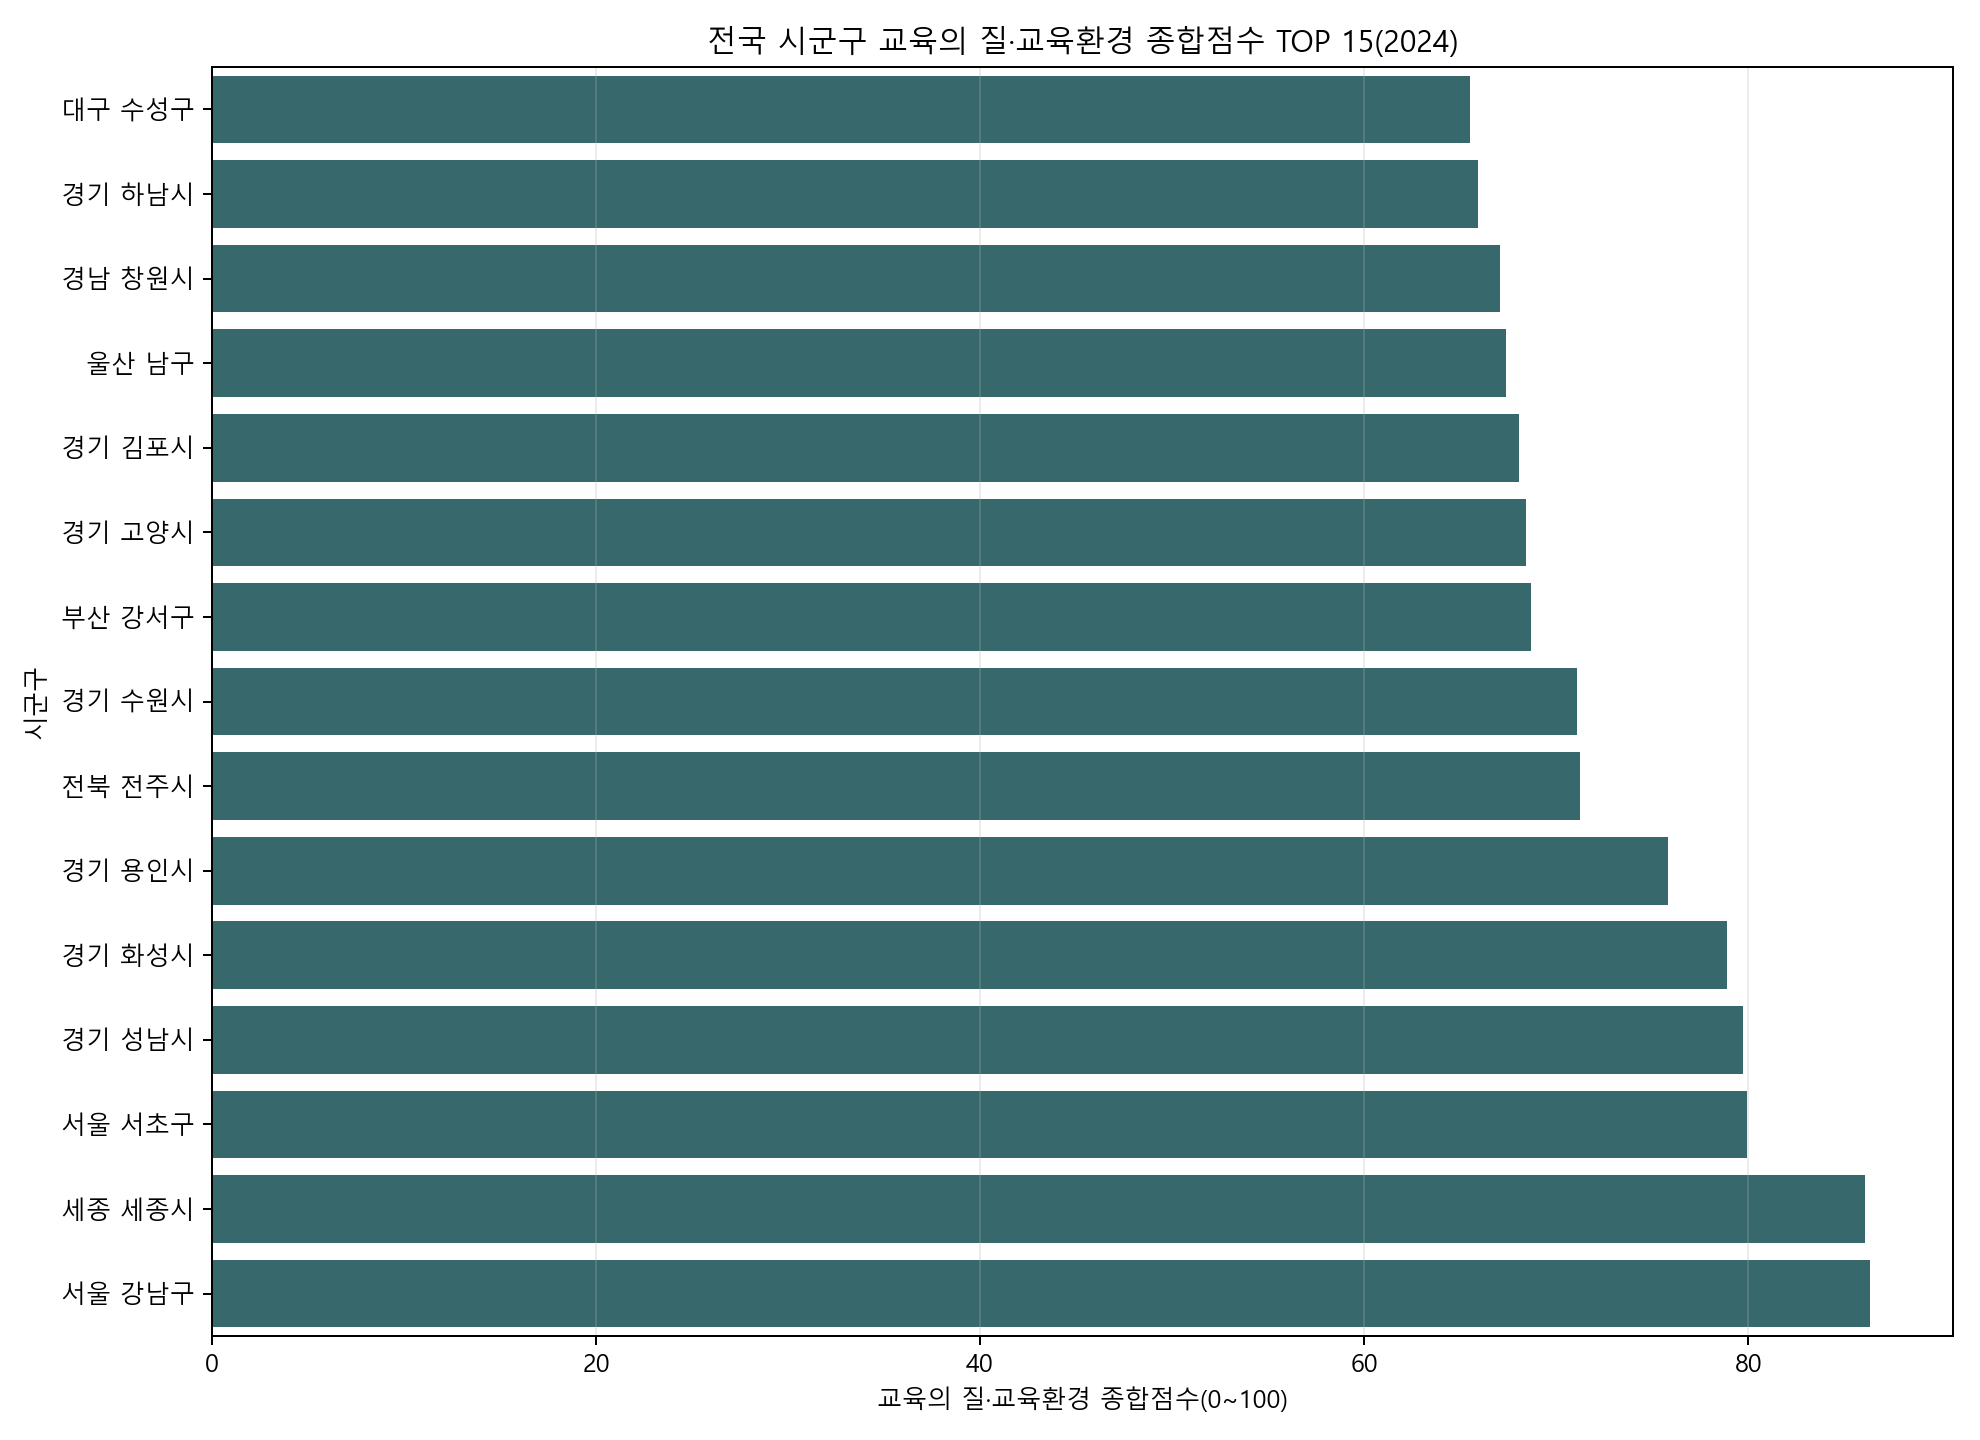

education_quality_environment_components_2024.png


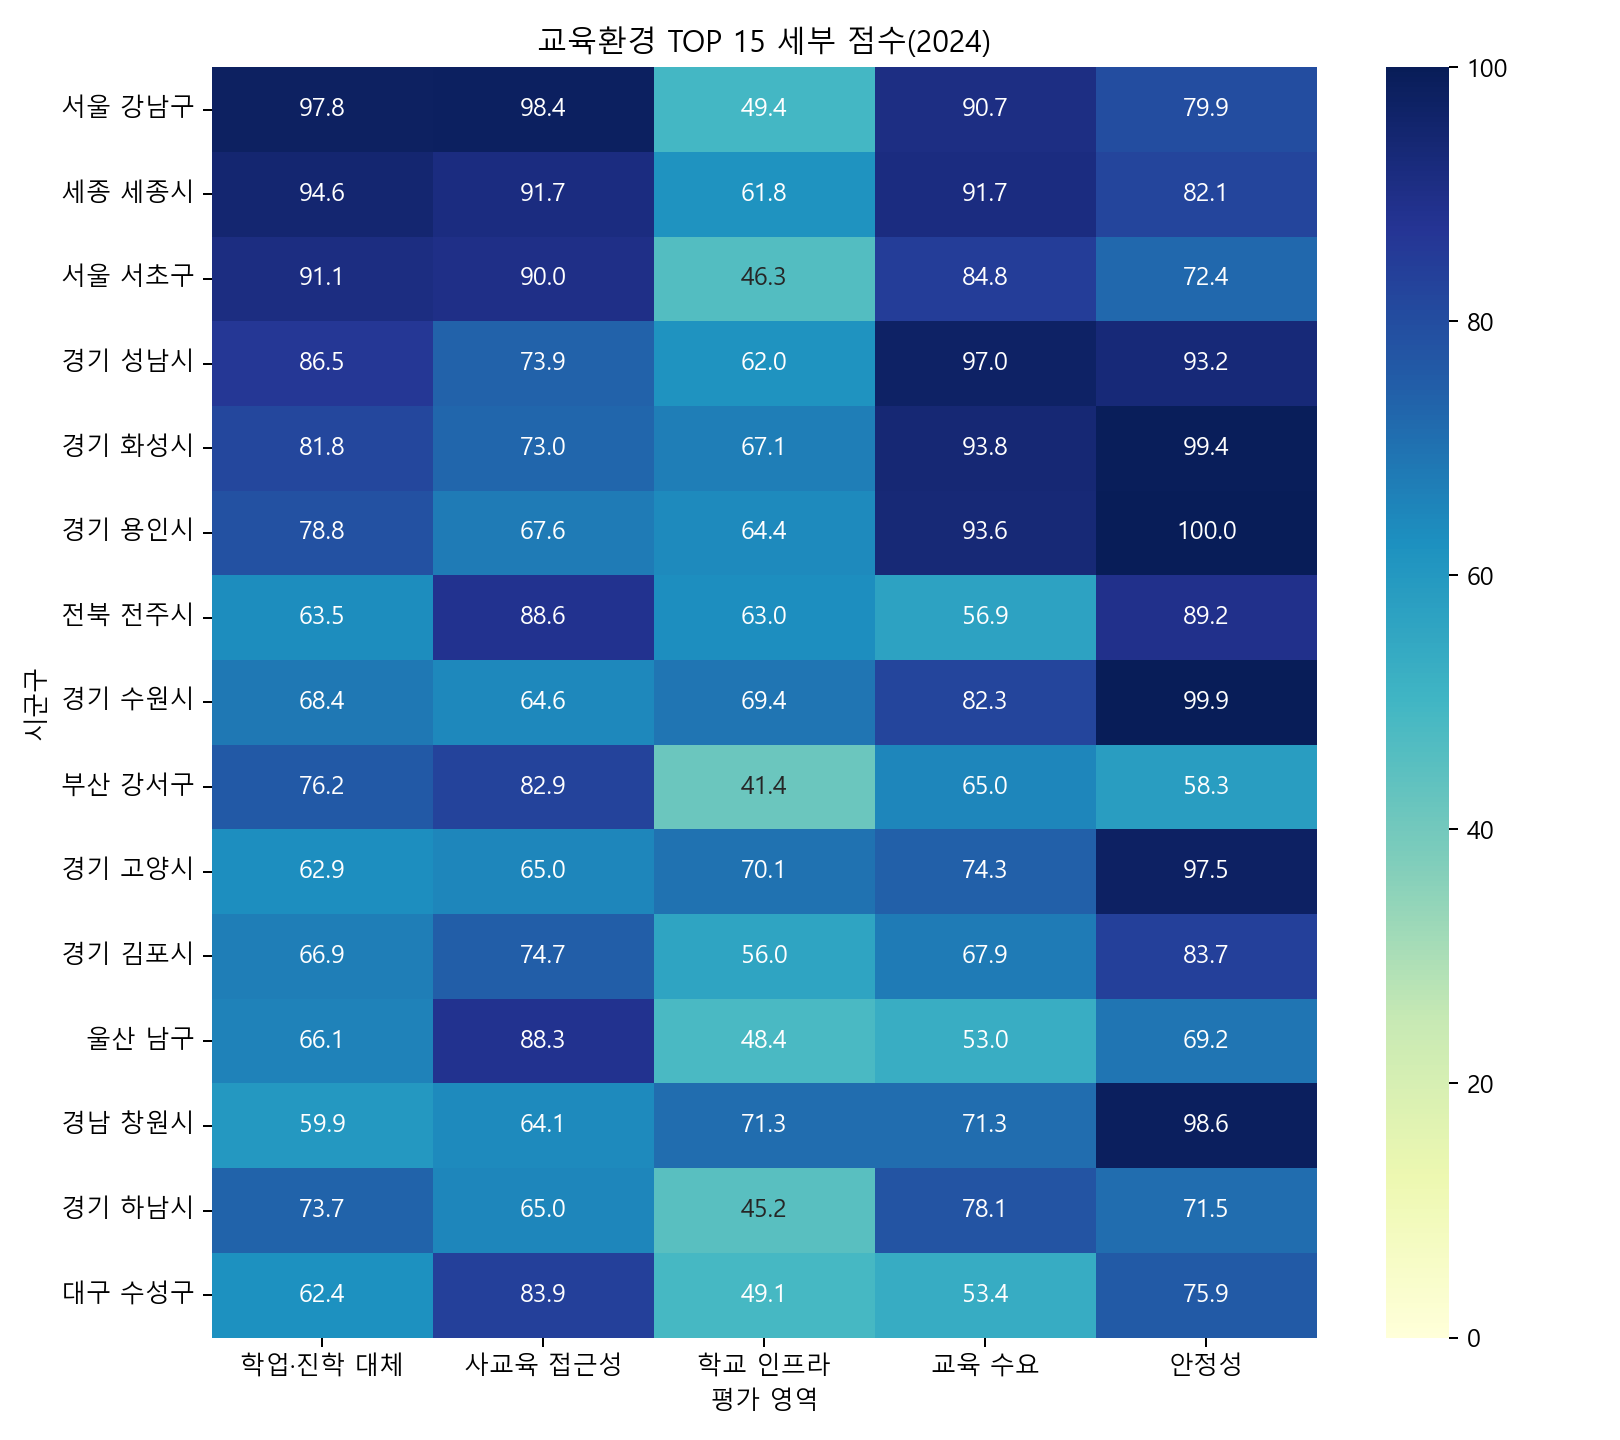

education_quality_environment_trend_2016_2024.png


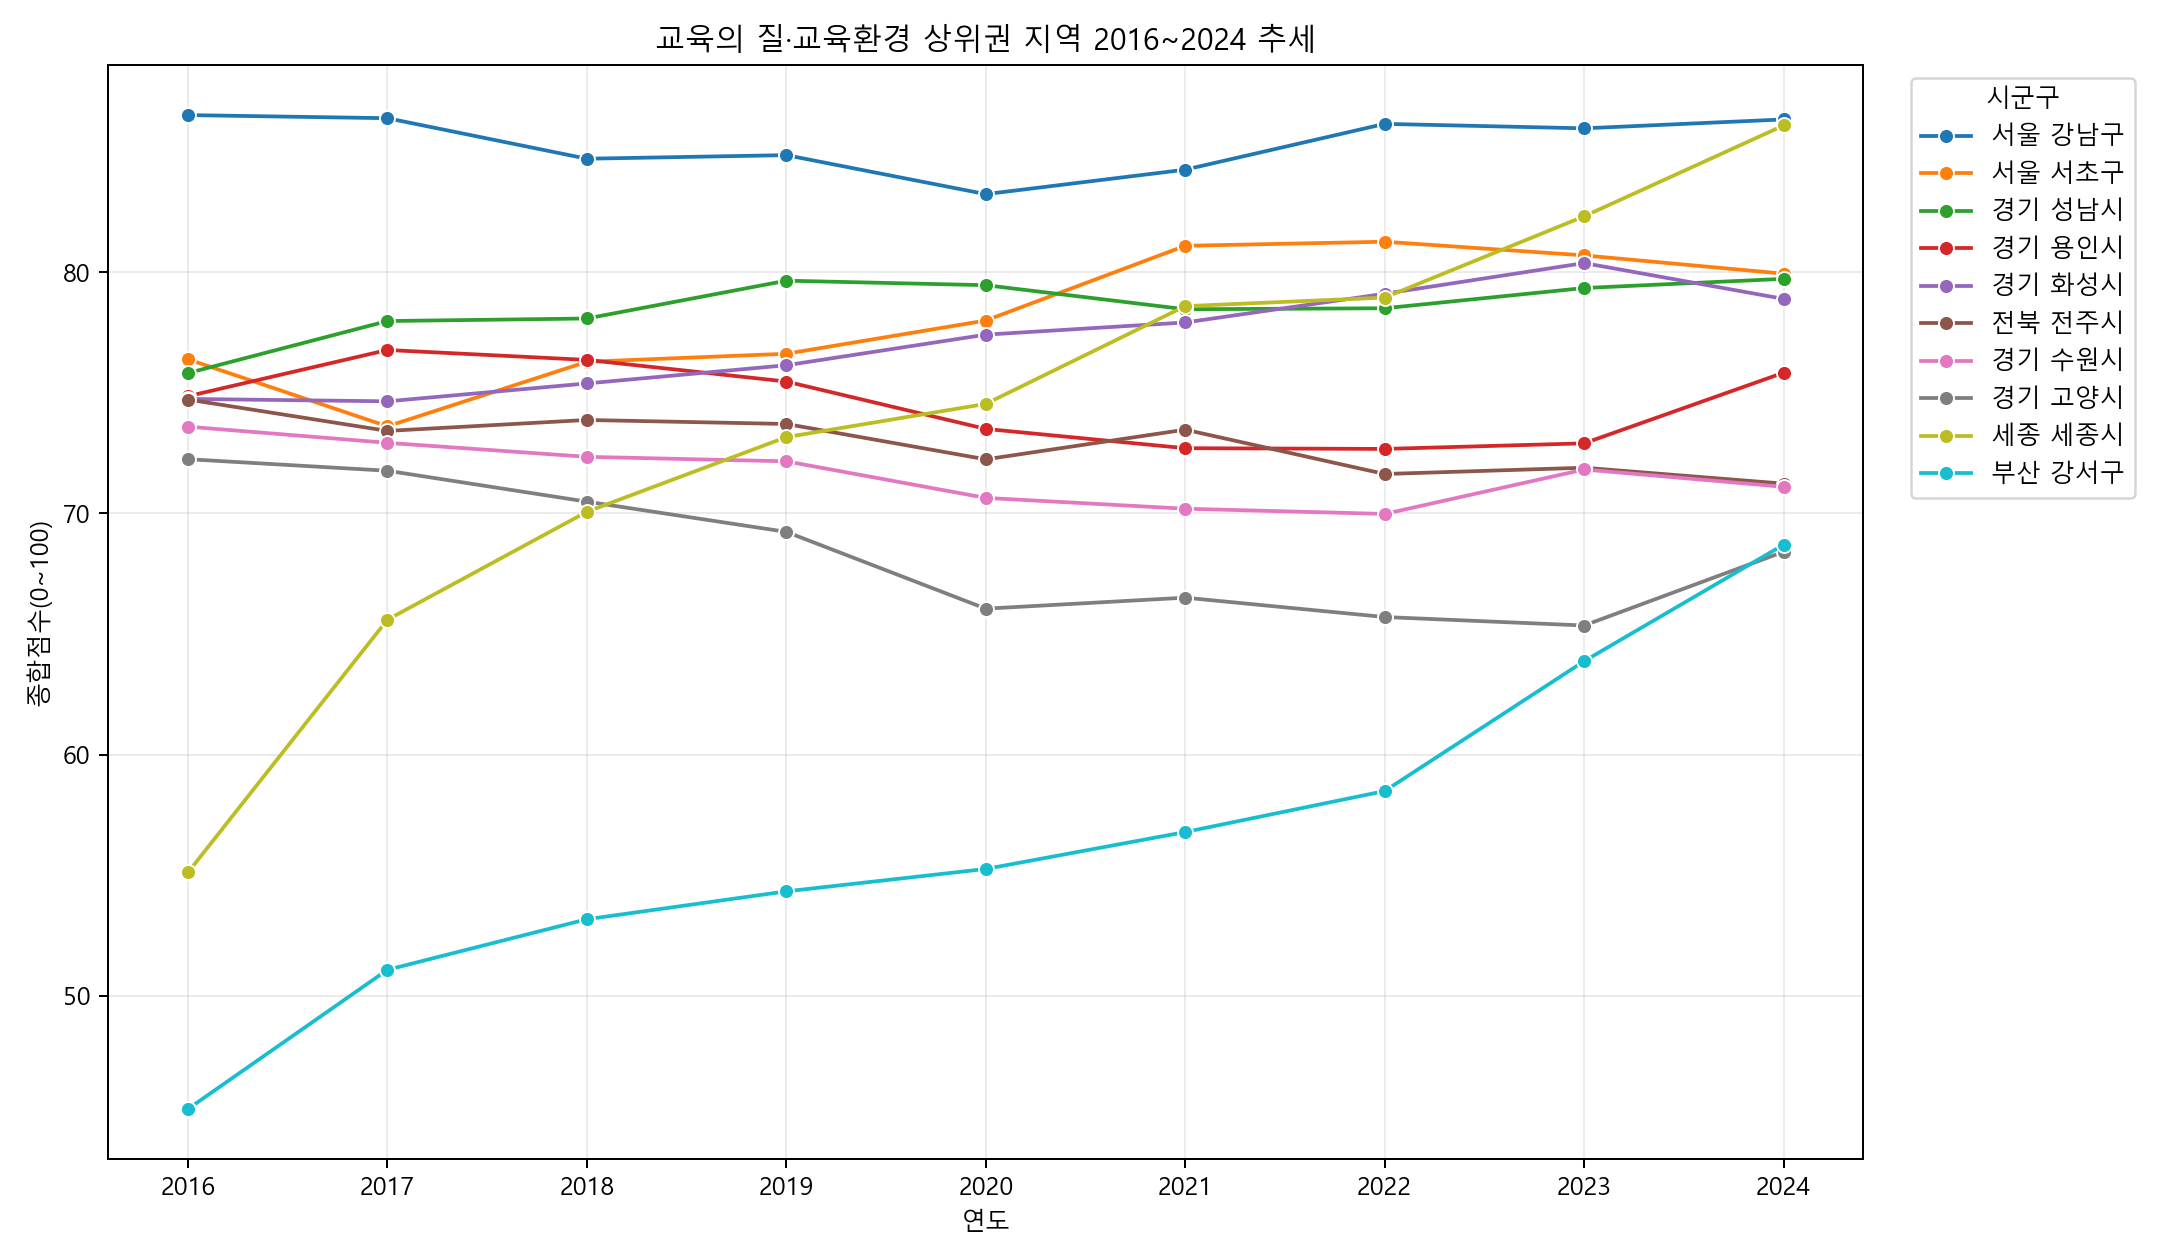

education_quality_environment_correlation_2024.png


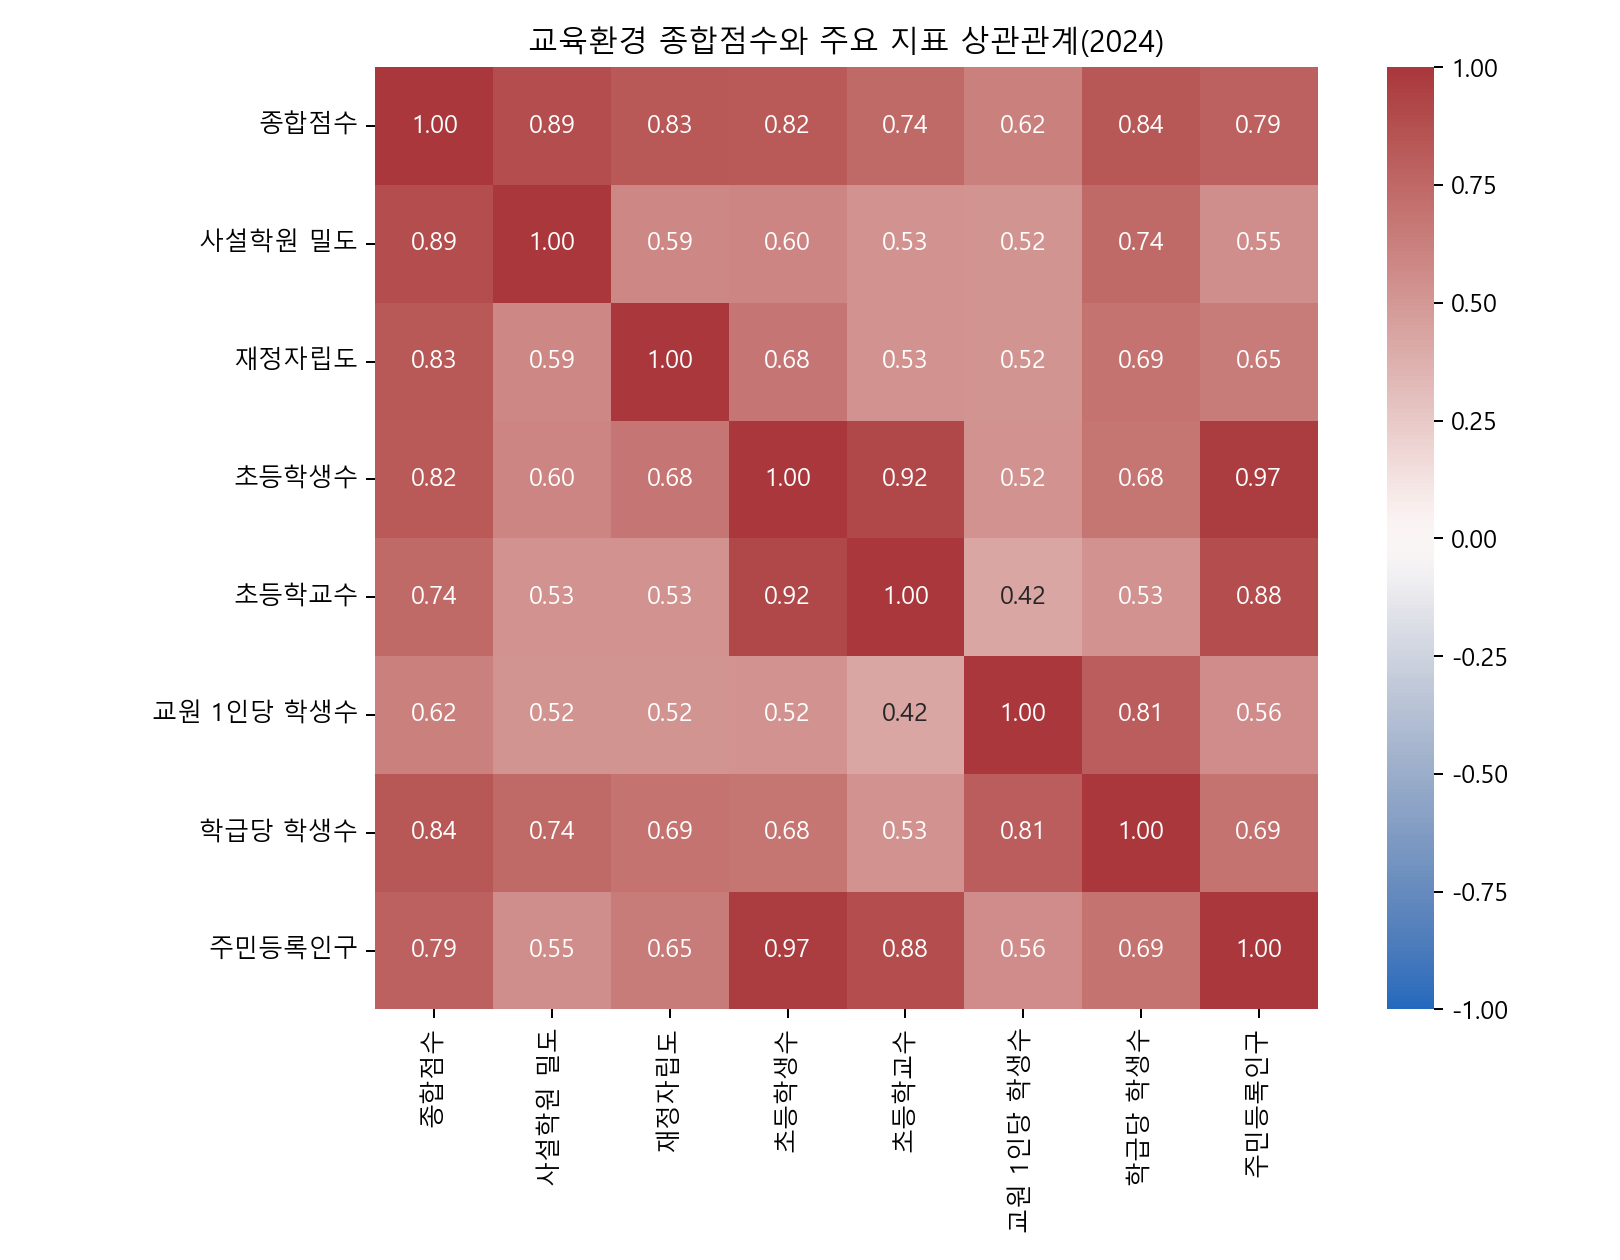

In [13]:
for image_name in [
    "education_quality_environment_top15_2024.png",
    "education_quality_environment_components_2024.png",
    "education_quality_environment_trend_2016_2024.png",
    "education_quality_environment_correlation_2024.png",
]:
    print(image_name)
    display(Image(filename=str(VIZ_DIR / image_name)))

## 15. 시각화 해석

TOP 15 그래프에서는 서울 강남구가 가장 높은 종합점수를 보이고, 세종 세종시와 서울 서초구가 뒤를 잇는다. 이는 사교육 접근성, 재정 여건, 교육 수요, 안정성을 함께 고려한 결과다.

세부 점수 heatmap은 각 지역이 어떤 영역에서 높은지 보여준다. 강남구는 사교육 접근성과 학업·진학 대체점수가 특히 높다. 세종시는 사교육 접근성, 교육 수요, 학교 인프라가 비교적 균형적으로 높다. 성남시, 화성시, 용인시, 수원시 등은 학생 수와 인구 규모가 커 안정성 및 교육 수요 측면에서 강하게 나타난다.

2016~2024 추세 그래프는 상위권 지역의 점수가 시간에 따라 어떻게 변했는지 보여준다. 상관관계 heatmap은 최종 종합점수가 어떤 원지표와 강하게 연결되는지 확인하기 위한 자료다.

## 16. 분석 한계

이번 분석은 확보 가능한 KOSIS 시군구 지표만으로 만든 탐색적 종합지표다. 따라서 다음 한계가 있다.

1. 학업성취도와 진학률이 직접 반영되지 않았다.
   - 시군구 단위 학업성취도, 대학 진학률, 특목고·자사고 진학률 자료가 없어서 대체지표를 사용했다.

2. 경기권 대표 학군지가 세부 구 단위로 나뉘지 않는다.
   - 분당구는 성남시, 수지구는 용인시, 영통구는 수원시, 일산동구·일산서구는 고양시로 집계된다.

3. 사교육 접근성은 학원 수 밀도를 중심으로 보았다.
   - 학원의 질, 입시 실적, 과목별 전문성, 대형 학원가 형성 정도까지는 반영하지 못했다.

4. 재정자립도는 교육 소비 여력의 완전한 대체지표가 아니다.
   - 실제 가구소득, 주택가격, 교육비 지출 자료가 있으면 더 정교한 분석이 가능하다.

5. 학교 인프라는 초등학교 중심 지표가 많다.
   - 중학교, 고등학교, 특목고, 자사고, 과학고, 외고 자료가 추가되면 진학환경 분석력이 좋아진다.

## 17. 추가로 확보하면 좋은 데이터

분석을 더 현실적인 학군 경쟁력 순위에 가깝게 만들려면 다음 자료가 필요하다.

- 학교알리미 학교별 학업성취도 또는 평가 관련 지표
- 학교별 대학 진학률
- 특목고, 자사고, 과학고, 외고 진학률
- 중학교·고등학교 학생 수와 학교 수
- 행정동 또는 구 단위 학원 수
- 독서실, 스터디카페, 교육시설 자료
- 가구소득, 주택가격, 교육비 지출 자료
- 학교별 방과후, 진로, 심화 프로그램 운영 자료

이 자료들이 추가되면 현재의 대체지표 방식보다 훨씬 직접적인 교육의 질·진학환경 분석이 가능하다.

## 18. 최종 정리

본 분석은 KOSIS e-지방지표에서 확보 가능한 시군구 단위 교육·인구·재정 자료를 활용해 교육환경 종합점수를 산출했다. 분석 과정에서는 단순 비율 지표가 작은 지역을 과대평가하지 않도록 log scaling, winsorization, 안정성 보정을 적용했다.

최종적으로 교육환경 종합점수는 다음을 결합한 지표다.

```text
교육환경 종합점수 = 학업·진학 대체점수 + 사교육 접근성 + 학교 인프라 + 지역 교육 수요 + 안정성 보정
```

따라서 이 결과는 절대적인 공교육 성과 순위가 아니라, 학생과 학부모가 체감할 수 있는 교육환경과 학군 경쟁력을 설명하기 위한 탐색적 종합지표로 해석하는 것이 적절하다.